# Análisis de Datos Clínicos — Puebla (5,000 pacientes)

Este notebook explora el dataset `dataset_clinico_puebla_5000.csv`, que contiene información clínica de 5,000 pacientes de distintos municipios de Puebla: signos vitales, hábitos, diagnósticos y nivel de riesgo.

**Contenido:**
1. Carga y vista general de los datos
2. Limpieza y calidad de datos
3. Estadísticas descriptivas
4. Análisis demográfico
5. Análisis clínico (IMC, presión, glucosa, colesterol)
6. Diagnósticos y nivel de riesgo
7. Correlaciones
8. Conclusiones


## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('dataset_clinico_puebla_5000.csv', encoding='utf-8-sig')
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 5000 filas x 25 columnas


,ID_Paciente,Nombre,Apellido,Sexo,Edad,Municipio,Peso_kg,Estatura_m,IMC,Presion_Sistolica,Presion_Diastolica,Frecuencia_Cardiaca,Temperatura,Saturacion_O2,Glucosa,Colesterol,Trigliceridos,Fuma,Alcohol,Actividad_Fisica,Diabetes,Hipertension,Obesidad,Diagnostico,Riesgo
0,1,Juan,Pérez,Masculino,21,Tehuacán,76.3,1.75,24.91,135,75,68,36.5,92,127,165,258,Sí,Sí,Media,Sí,No,No,Paciente sano,Bajo
1,2,Carlos,Hernández,Masculino,87,San Pedro Cholula,96.3,1.77,30.74,153,74,103,36.7,93,184,280,141,Sí,Sí,Media,Sí,Sí,Sí,Obesidad,Alto
2,3,José,Sánchez,Femenino,30,San Andrés Cholula,65.2,1.58,26.12,145,82,108,37.4,97,137,141,256,No,Sí,Alta,Sí,Sí,No,Gastritis,Medio
3,4,Laura,González,Masculino,26,Atlixco,87.2,1.83,26.04,105,74,78,36.8,96,144,150,288,Sí,Sí,Baja,Sí,No,No,Paciente sano,Bajo
4,5,Juan,López,Masculino,39,Puebla,84.5,1.69,29.59,168,75,106,36.7,96,111,248,167,No,Sí,Media,No,Sí,No,Paciente sano,Bajo


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Paciente          5000 non-null   int64  
 1   Nombre               5000 non-null   str    
 2   Apellido             5000 non-null   str    
 3   Sexo                 5000 non-null   str    
 4   Edad                 5000 non-null   int64  
 5   Municipio            5000 non-null   str    
 6   Peso_kg              5000 non-null   float64
 7   Estatura_m           5000 non-null   float64
 8   IMC                  5000 non-null   float64
 9   Presion_Sistolica    5000 non-null   int64  
 10  Presion_Diastolica   5000 non-null   int64  
 11  Frecuencia_Cardiaca  5000 non-null   int64  
 12  Temperatura          5000 non-null   float64
 13  Saturacion_O2        5000 non-null   int64  
 14  Glucosa              5000 non-null   int64  
 15  Colesterol           5000 non-null   int64  
 16 

## 2. Limpieza y calidad de datos

Verificamos valores nulos, duplicados y rangos válidos de las variables numéricas.

In [3]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")

# Duplicados
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"IDs de paciente duplicados: {df['ID_Paciente'].duplicated().sum()}")


Valores nulos por columna:
0 valores nulos en total

Filas duplicadas: 0
IDs de paciente duplicados: 0


In [4]:
# Rango de variables numéricas clave
cols_num = ['Edad', 'Peso_kg', 'Estatura_m', 'IMC', 'Presion_Sistolica',
            'Presion_Diastolica', 'Frecuencia_Cardiaca', 'Temperatura',
            'Saturacion_O2', 'Glucosa', 'Colesterol', 'Trigliceridos']
df[cols_num].describe().T


,count,mean,std,min,25%,50%,75%,max
Edad,5000.0,54.340600,21.097081,18.00,36.00,54.00,73.00,90.00
Peso_kg,5000.0,73.100520,12.854462,45.00,64.40,73.00,81.90,120.30
Estatura_m,5000.0,1.659948,0.092240,1.33,1.59,1.66,1.73,1.94
IMC,5000.0,26.649974,4.954366,14.04,23.15,26.46,29.86,50.27
Presion_Sistolica,5000.0,135.144200,20.606764,100.00,117.00,136.00,153.00,170.00
Presion_Diastolica,5000.0,79.931000,11.869727,60.00,70.00,80.00,90.00,100.00
Frecuencia_Cardiaca,5000.0,82.376800,16.307851,55.00,68.00,82.00,96.00,110.00
Temperatura,5000.0,37.091700,0.639117,36.00,36.50,37.10,37.70,38.20
Saturacion_O2,5000.0,95.997800,2.567316,92.00,94.00,96.00,98.00,100.00
Glucosa,5000.0,144.995800,43.631563,70.00,107.00,145.00,183.00,220.00


## 3. Estadísticas descriptivas generales

In [5]:
print("Distribución por Sexo:")
print(df['Sexo'].value_counts())
print("\nDistribución por Municipio (top 10):")
print(df['Municipio'].value_counts().head(10))


Distribución por Sexo:
Sexo
Masculino    2511
Femenino     2489
Name: count, dtype: int64

Distribución por Municipio (top 10):
Municipio
Amozoc                539
San Andrés Cholula    537
Atlixco               528
Tehuacán              515
Huauchinango          501
Puebla                493
Cuautlancingo         486
San Pedro Cholula     481
Zacatlán              465
Teziutlán             455
Name: count, dtype: int64


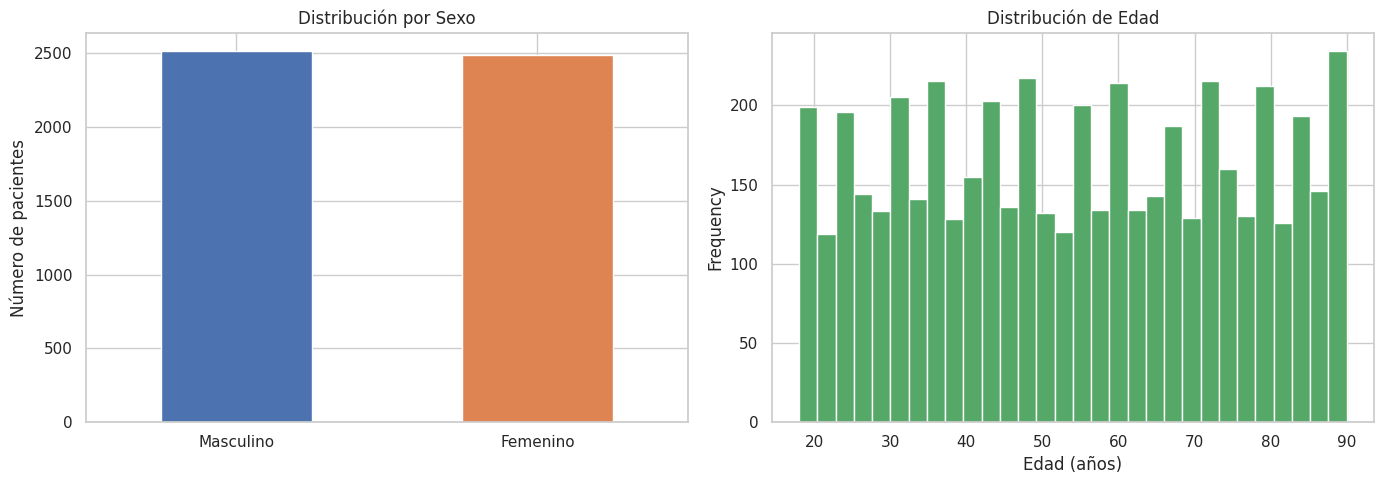

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Sexo'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribución por Sexo')
axes[0].set_xlabel('')
axes[0].set_ylabel('Número de pacientes')
axes[0].tick_params(axis='x', rotation=0)

df['Edad'].plot(kind='hist', bins=30, ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('Distribución de Edad')
axes[1].set_xlabel('Edad (años)')

plt.tight_layout()
plt.show()


## 4. Análisis demográfico por municipio

/tmp/ipykernel_567/2208400813.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_municipios.values, y=top_municipios.index, palette='viridis')


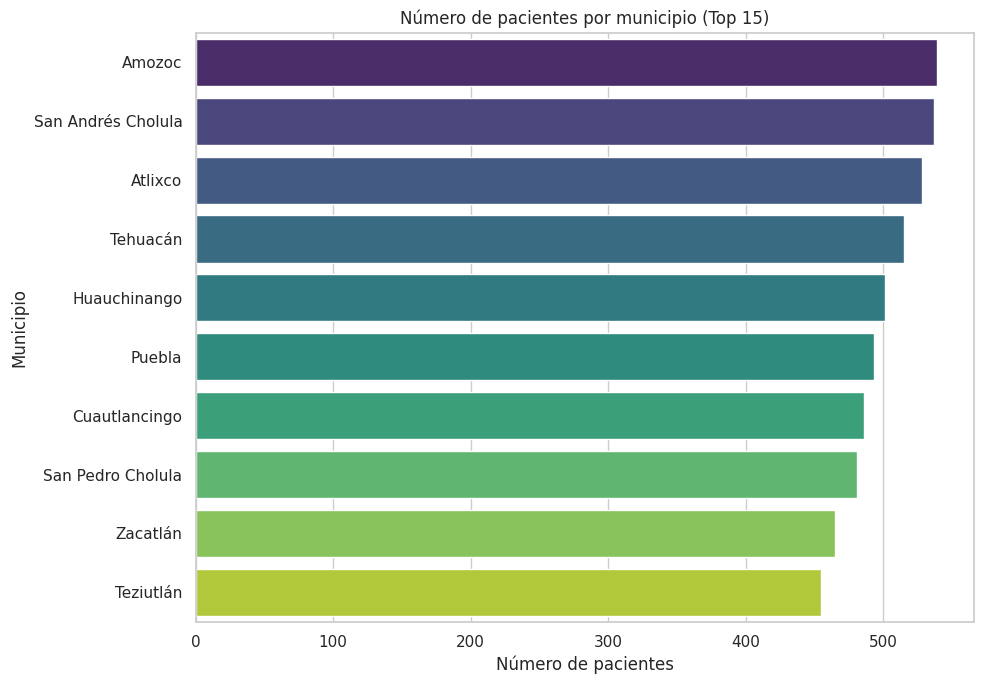

In [7]:
top_municipios = df['Municipio'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_municipios.values, y=top_municipios.index, palette='viridis')
plt.title('Número de pacientes por municipio (Top 15)')
plt.xlabel('Número de pacientes')
plt.ylabel('Municipio')
plt.tight_layout()
plt.show()


In [8]:
# Edad promedio por municipio
edad_municipio = df.groupby('Municipio')['Edad'].mean().sort_values(ascending=False).head(10)
edad_municipio


Municipio
San Pedro Cholula     55.515593
Atlixco               54.964015
Tehuacán              54.743689
San Andrés Cholula    54.722533
Zacatlán              54.290323
Amozoc                54.094620
Puebla                53.987830
Cuautlancingo         53.851852
Huauchinango          53.730539
Teziutlán             53.386813
Name: Edad, dtype: float64

## 5. Análisis clínico

Exploramos las variables clínicas principales: IMC, presión arterial, glucosa y colesterol.

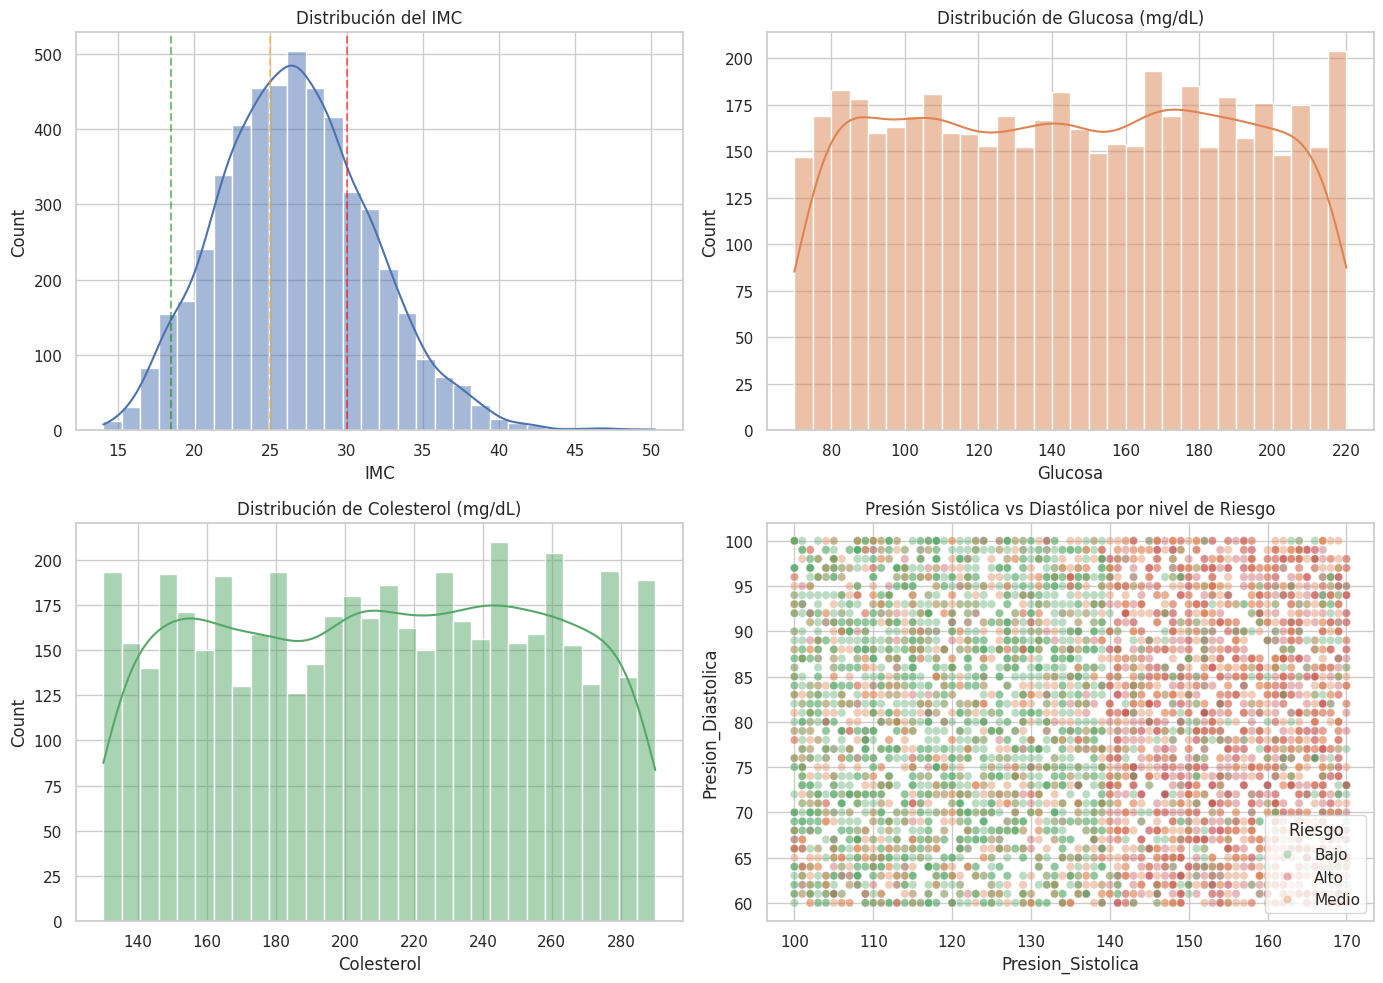

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['IMC'], bins=30, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Distribución del IMC')
axes[0,0].axvline(18.5, color='green', linestyle='--', alpha=0.5)
axes[0,0].axvline(25, color='orange', linestyle='--', alpha=0.5)
axes[0,0].axvline(30, color='red', linestyle='--', alpha=0.5)

sns.histplot(df['Glucosa'], bins=30, kde=True, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Distribución de Glucosa (mg/dL)')

sns.histplot(df['Colesterol'], bins=30, kde=True, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Distribución de Colesterol (mg/dL)')

sns.scatterplot(data=df, x='Presion_Sistolica', y='Presion_Diastolica',
                 hue='Riesgo', alpha=0.4, ax=axes[1,1],
                 palette={'Bajo':'#55A868','Medio':'#DD8452','Alto':'#C44E52'})
axes[1,1].set_title('Presión Sistólica vs Diastólica por nivel de Riesgo')

plt.tight_layout()
plt.show()


/tmp/ipykernel_567/805451375.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Categoria_IMC', order=orden, palette='coolwarm')


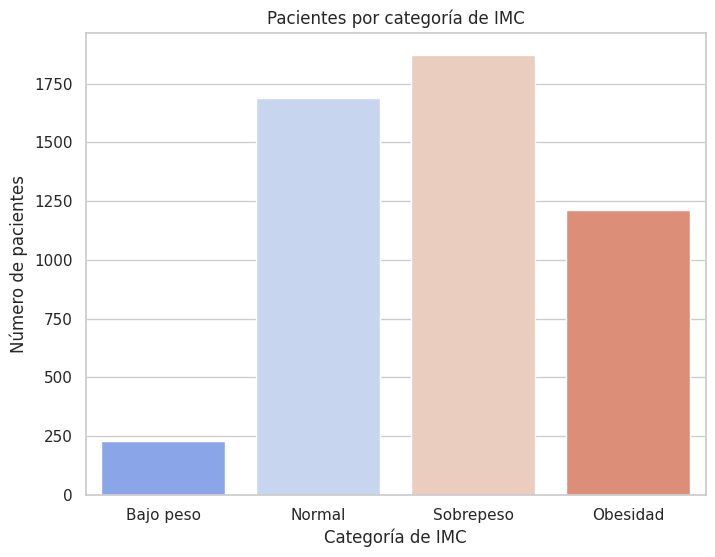

In [10]:
# Clasificación de IMC
def clasificar_imc(imc):
    if imc < 18.5:
        return 'Bajo peso'
    elif imc < 25:
        return 'Normal'
    elif imc < 30:
        return 'Sobrepeso'
    else:
        return 'Obesidad'

df['Categoria_IMC'] = df['IMC'].apply(clasificar_imc)

plt.figure(figsize=(8, 6))
orden = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
sns.countplot(data=df, x='Categoria_IMC', order=orden, palette='coolwarm')
plt.title('Pacientes por categoría de IMC')
plt.xlabel('Categoría de IMC')
plt.ylabel('Número de pacientes')
plt.show()


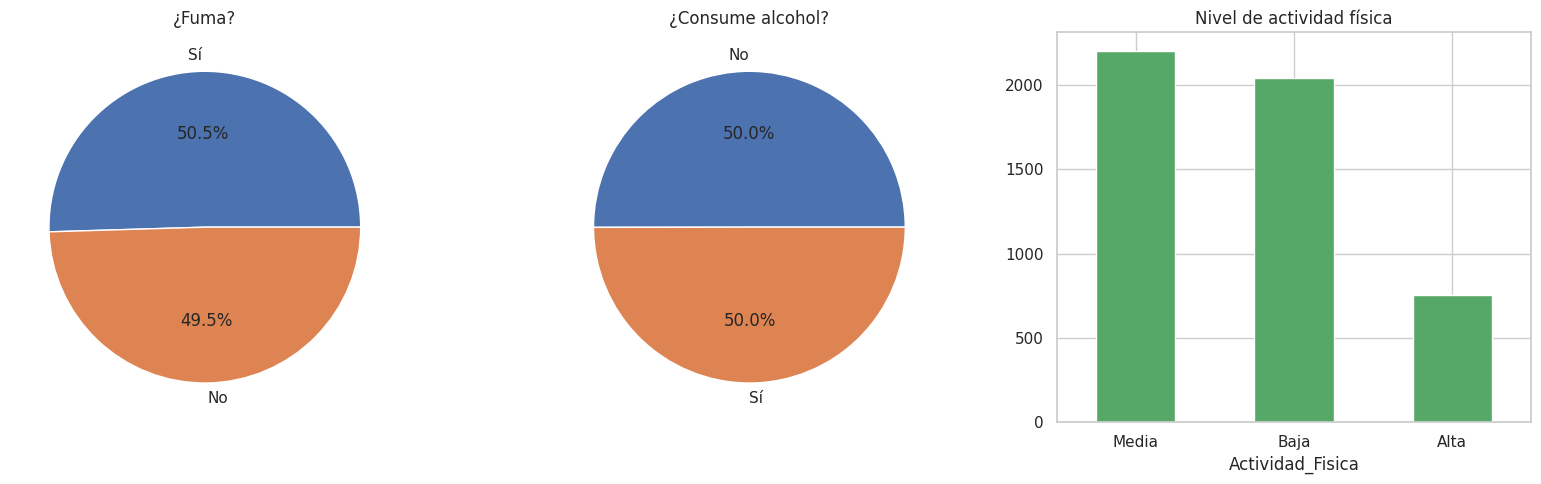

In [11]:
# Hábitos: tabaquismo, alcohol y actividad física
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['Fuma'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#4C72B0','#DD8452'])
axes[0].set_title('¿Fuma?')
axes[0].set_ylabel('')

df['Alcohol'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], colors=['#4C72B0','#DD8452'])
axes[1].set_title('¿Consume alcohol?')
axes[1].set_ylabel('')

df['Actividad_Fisica'].value_counts().plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Nivel de actividad física')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 6. Diagnósticos y nivel de riesgo

/tmp/ipykernel_567/851702592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Diagnostico', order=orden_diag, palette='mako')


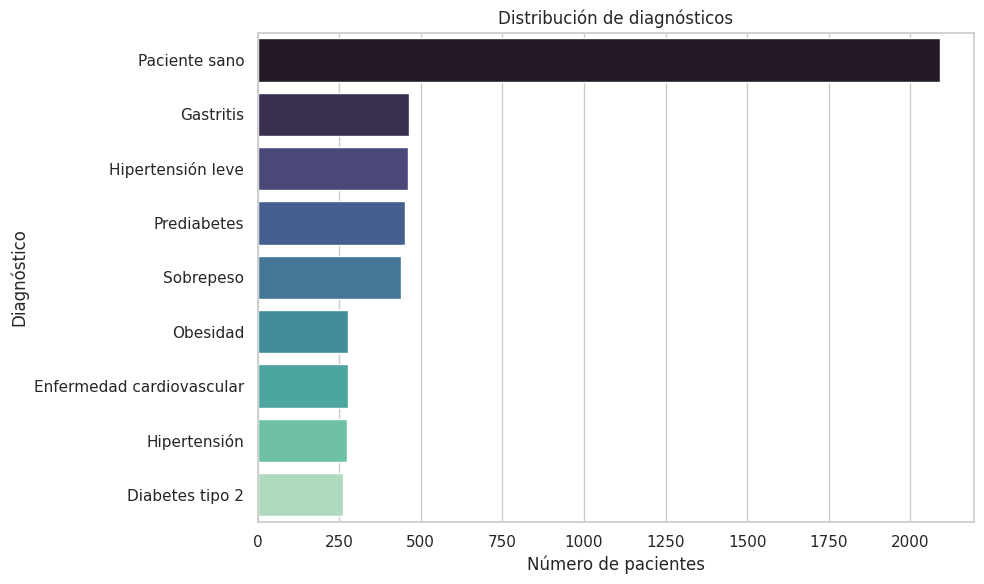

In [12]:
plt.figure(figsize=(10, 6))
orden_diag = df['Diagnostico'].value_counts().index
sns.countplot(data=df, y='Diagnostico', order=orden_diag, palette='mako')
plt.title('Distribución de diagnósticos')
plt.xlabel('Número de pacientes')
plt.ylabel('Diagnóstico')
plt.tight_layout()
plt.show()


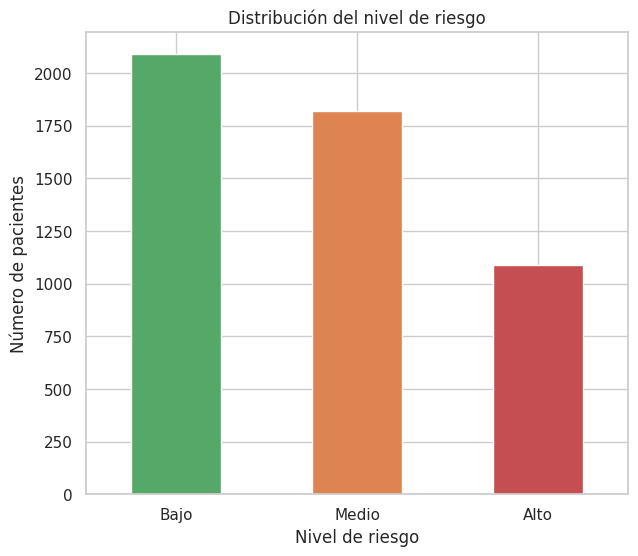

In [13]:
plt.figure(figsize=(7, 6))
colores = {'Bajo':'#55A868','Medio':'#DD8452','Alto':'#C44E52'}
df['Riesgo'].value_counts().reindex(['Bajo','Medio','Alto']).plot(
    kind='bar', color=[colores[r] for r in ['Bajo','Medio','Alto']])
plt.title('Distribución del nivel de riesgo')
plt.xlabel('Nivel de riesgo')
plt.ylabel('Número de pacientes')
plt.xticks(rotation=0)
plt.show()


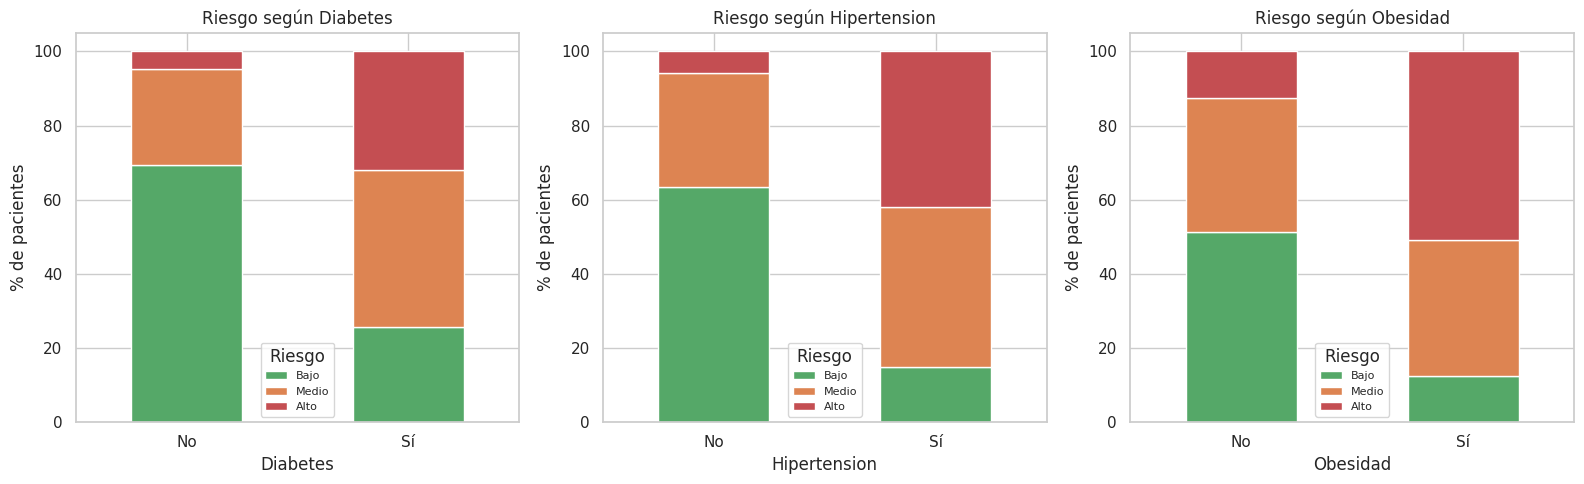

In [14]:
# Riesgo por condiciones crónicas
condiciones = ['Diabetes', 'Hipertension', 'Obesidad']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cond in zip(axes, condiciones):
    tabla = pd.crosstab(df[cond], df['Riesgo'], normalize='index') * 100
    tabla = tabla[['Bajo','Medio','Alto']]
    tabla.plot(kind='bar', stacked=True, ax=ax, color=['#55A868','#DD8452','#C44E52'])
    ax.set_title(f'Riesgo según {cond}')
    ax.set_ylabel('% de pacientes')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Riesgo', fontsize=8)

plt.tight_layout()
plt.show()


## 7. Correlación entre variables clínicas numéricas

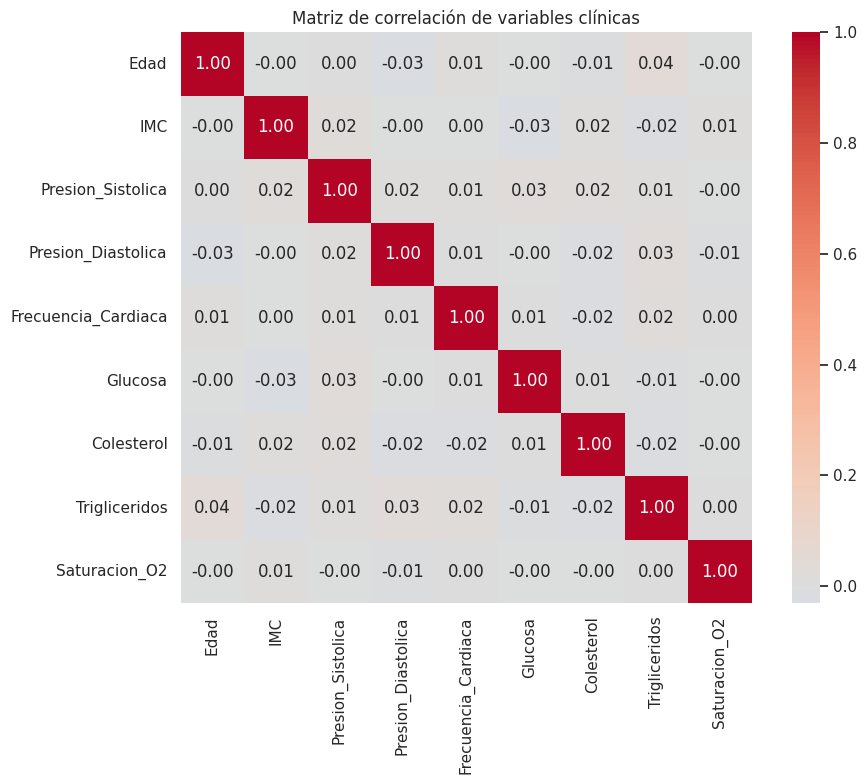

In [15]:
cols_corr = ['Edad', 'IMC', 'Presion_Sistolica', 'Presion_Diastolica',
             'Frecuencia_Cardiaca', 'Glucosa', 'Colesterol', 'Trigliceridos', 'Saturacion_O2']

plt.figure(figsize=(10, 8))
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlación de variables clínicas')
plt.tight_layout()
plt.show()


## 8. Conclusiones

Edita esta celda con los hallazgos relevantes para tu análisis, por ejemplo:

- Proporción de pacientes por nivel de riesgo (Bajo / Medio / Alto).
- Municipios con mayor número de pacientes y su perfil de edad.
- Relación entre hábitos (tabaquismo, alcohol, actividad física) y diagnóstico.
- Variables clínicas más correlacionadas entre sí (por ejemplo, IMC vs presión arterial).

Este notebook puede extenderse fácilmente agregando modelos predictivos (por ejemplo, clasificación de riesgo) usando `scikit-learn`.
